In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
# Define the paths to your image folders (relative to the server's root)
leak_folder = r'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Gear Fault Data'
non_leak_folder = r'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Normal Data'
print("--------------------------------------\n")

--------------------------------------



In [3]:
# Create empty lists to store images and labels
images = []
labels = []

In [4]:
# Load leak images and count them
num_leak_images = 0 
for filename in os.listdir(leak_folder):
    img_path = os.path.join(leak_folder, filename)
    img = cv2.imread(img_path)  
    images.append(img)
    labels.append(1)
    num_leak_images += 1 

# Load non-leak images and count them
num_non_leak_images = 0
for filename in os.listdir(non_leak_folder):
    img_path = os.path.join(non_leak_folder, filename)
    img = cv2.imread(img_path)
    images.append(img)
    labels.append(0)
    num_non_leak_images += 1

In [5]:
print(f"Number of leak images: {num_leak_images}")
print(f"Number of non-leak images: {num_non_leak_images}")
print(f"Total number of images: {len(images)}")

Number of leak images: 80
Number of non-leak images: 80
Total number of images: 160


In [6]:
import cv2

image_info = cv2.imread(os.path.join(leak_folder, os.listdir(leak_folder)[1]))
height, width, channels = image_info.shape

print(f"Image Height: {height}")
print(f"Image Width: {width}")
print(f"Image Channels: {channels}")

Image Height: 656
Image Width: 875
Image Channels: 3


In [7]:
images =np.array(images)
labels = np.array(labels)


In [8]:
print("--------------------------------------\n")
print('Dataset Length: ',len(images))
print('Label Length: ',len(labels))
print("--------------------------------------\n")

--------------------------------------

Dataset Length:  160
Label Length:  160
--------------------------------------



In [9]:

print("--------------------------------------\n")
print("Train-Test Split")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
print("--------------------------------------\n")

--------------------------------------

Train-Test Split
--------------------------------------



In [10]:
# Print the sizes of each split
print(f"Number of images in X_train: {len(X_train)}")
print(f"Number of images in X_test: {len(X_test)}")
print(f"Number of labels in y_train: {len(y_train)}")
print(f"Number of labels in y_test: {len(y_test)}")

Number of images in X_train: 128
Number of images in X_test: 32
Number of labels in y_train: 128
Number of labels in y_test: 32


In [11]:
# Define input shape based on image dimensions
input_shape = X_train[0].shape
input_shape

(656, 875, 3)

In [12]:
from tensorflow.keras.utils import to_categorical

# Ensure labels are one-hot encoded
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)


In [13]:
def resize_images(image_array, target_size=(128, 128)):
    resized_images = []
    for img in image_array:
        resized_img = cv2.resize(img, target_size)
        resized_images.append(resized_img)
    return np.array(resized_images)

# Resize images
X_train_resized = resize_images(X_train, target_size=(128, 128))
X_test_resized = resize_images(X_test, target_size=(128, 128))

# Verify the new shapes
print("Resized X_train shape:", X_train_resized.shape)
print("Resized X_test shape:", X_test_resized.shape)


Resized X_train shape: (128, 128, 128, 3)
Resized X_test shape: (32, 128, 128, 3)


In [14]:
def create_sequences(data, labels, seq_length):
    sequences = []
    seq_labels = []
    for i in range(0, len(data) - seq_length + 1, seq_length):
        sequences.append(data[i:i + seq_length])
        seq_labels.append(labels[i + seq_length - 1])  # Use the label of the last frame in the sequence
    return np.array(sequences), np.array(seq_labels)

# Sequence length
sequence_length = 10

# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_resized, y_train, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_resized, y_test, sequence_length)

# One-hot encode the labels
y_train_seq = to_categorical(y_train_seq, num_classes=2)
y_test_seq = to_categorical(y_test_seq, num_classes=2)

# Check the shapes
print("X_train_seq shape:", X_train_seq.shape)  # Should be (num_sequences, sequence_length, 128, 128, 3)
print("y_train_seq shape:", y_train_seq.shape)  # Should be (num_sequences, 2)
print("X_test_seq shape:", X_test_seq.shape)    # Should be (num_sequences, sequence_length, 128, 128, 3)
print("y_test_seq shape:", y_test_seq.shape)    # Should be (num_sequences, 2)

X_train_seq shape: (12, 10, 128, 128, 3)
y_train_seq shape: (12, 2, 2)
X_test_seq shape: (3, 10, 128, 128, 3)
y_test_seq shape: (3, 2, 2)


In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(264, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(128, activation='relu')(x)  # Feature vector of size 128
    model = Model(inputs, outputs)
    return model

input_shape = X_train[0].shape
cnn_model = create_cnn_model(input_shape)
cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 656, 875, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 654, 873, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 327, 436, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 325, 434, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 162, 217, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 160, 215, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 107, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 78, 105, 264)   │       304,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 39, 52, 264)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 535392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    68,530,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,944,456 (263.00 MB)

 Trainable params: 68,944,456 (263.00 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
cnn_model.compile(optimizer='adam', loss='mse')  # Using 'mse' as we're just extracting features
cnn_features = cnn_model.predict(X_train)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


In [17]:
# Assuming the feature vector size from CNN is 128
X_train_lstm = cnn_features.reshape(X_train.shape[0], -1, 128)
X_test_lstm = cnn_model.predict(X_test).reshape(X_test.shape[0], -1, 128)

# Print shapes to verify
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
X_train_lstm shape: (128, 1, 128)
X_test_lstm shape: (32, 1, 128)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    return model

input_shape_lstm = X_train_lstm.shape[1:]
lstm_model = create_lstm_model(input_shape_lstm)
lstm_model.summary()


C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,473 (193.25 KB)

 Trainable params: 49,473 (193.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Convert one-hot encoded labels to binary labels if needed
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)
    y_test = np.argmax(y_test, axis=1)

# Verify the shapes of the labels
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


y_train shape: (128,)
y_test shape: (32,)


In [20]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_data=(X_test_lstm, y_test))

# Evaluate the LSTM model
loss, accuracy = lstm_model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy: {accuracy}")

# Generate predictions
y_pred = (lstm_model.predict(X_test_lstm) > 0.5).astype("int32")




Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.6010 - loss: 0.6357 - val_accuracy: 0.8125 - val_loss: 0.5429
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7406 - loss: 0.5308 - val_accuracy: 0.9062 - val_loss: 0.4971
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7521 - loss: 0.4783 - val_accuracy: 0.9062 - val_loss: 0.4513
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.4357 - val_accuracy: 1.0000 - val_loss: 0.4143
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8188 - loss: 0.4032 - val_accuracy: 0.7812 - val_loss: 0.3996
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8229 - loss: 0.3928 - val_accuracy: 0.8125 - val_loss: 0.3709
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9125 - loss: 0.3137 - val_accuracy: 1.0000 - val_loss: 0.3199
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9281 - loss: 0.3010 - val_accuracy: 1.0000 - val_loss: 0.3222
Epoch 9

In [21]:
# Use the best feature subset found by GA for final classification
#X_train_selected = X_train_lstm[:, :, best_features == 1]
#X_test_selected = X_test_lstm[:, :, best_features == 1]

final_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_lstm, y_train, epochs=400, batch_size=32, validation_data=(X_test_lstm, y_test))




Epoch 1/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.5250 - loss: 0.6824 - val_accuracy: 0.9062 - val_loss: 0.5956
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7625 - loss: 0.5658 - val_accuracy: 0.7812 - val_loss: 0.5275
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7885 - loss: 0.4983 - val_accuracy: 1.0000 - val_loss: 0.4734
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8104 - loss: 0.4727 - val_accuracy: 0.6562 - val_loss: 0.4526
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7865 - loss: 0.4390 - val_accuracy: 1.0000 - val_loss: 0.3795
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9146 - loss: 0.3604 - val_accuracy: 1.0000 - val_loss: 0.3480
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9333 - loss: 0.3087 - val_accuracy: 0.9688 - val_loss: 0.3312
Epoch 8/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9344 - loss: 0.2977 - val_accuracy: 1.0000 - val_loss: 

In [22]:
# Evaluate the final model
loss, accuracy = final_model.evaluate(X_test_lstm, y_test)
print(f"Final Test Accuracy: {accuracy}")

# Generate final predictions
y_pred_final = (final_model.predict(X_test_lstm) > 0.5).astype("int32")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 1.5683e-04
Final Test Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [23]:
# Display final classification report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



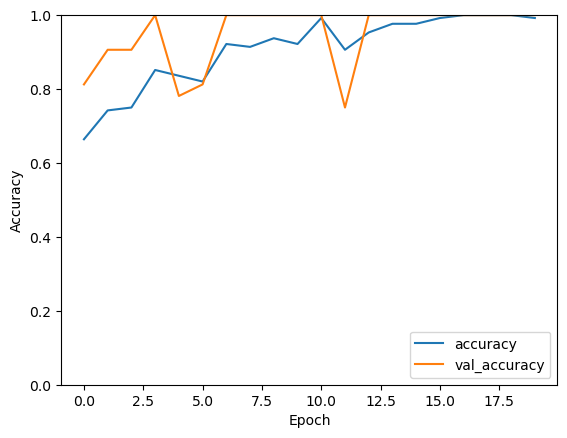

In [24]:
# Plot and save accuracy
plt.plot(history.epoch,history.history['accuracy'], label='accuracy')
plt.plot(history.epoch,history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right') 

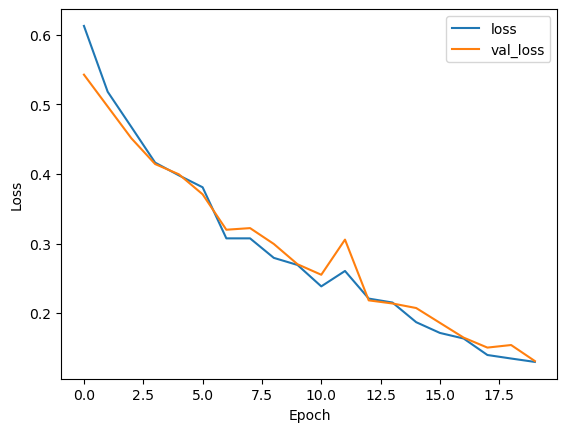

In [25]:
# Plot and save loss
plt.plot(history.epoch,history.history['loss'], label='loss')
plt.plot(history.epoch,history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [26]:
print("--------------------------------------\n")
print("Model Evalutaion Phase.\n")
loss,accuracy=final_model.evaluate(X_test_lstm,y_test)
print(f'Accuracy: {round(accuracy*100,2)}')
print("--------------------------------------\n")
y_pred=final_model.predict(X_test_lstm)
y_pred = (y_pred > 0.5).astype(int)

--------------------------------------

Model Evalutaion Phase.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 1.5683e-04
Accuracy: 100.0
--------------------------------------

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [27]:
print('classification Report\n',classification_report(y_test,y_pred))
print("--------------------------------------\n")

classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

--------------------------------------



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


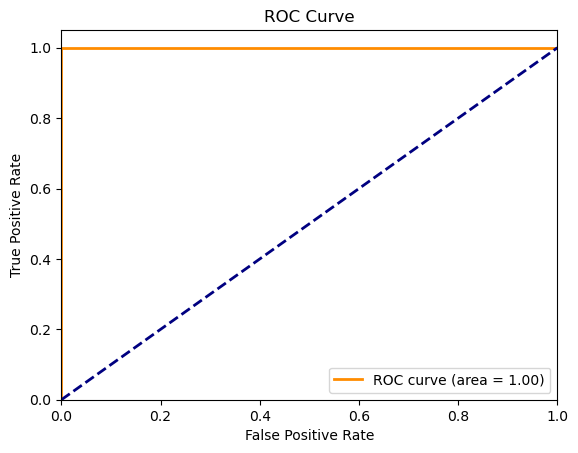

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba = final_model.predict(X_test_lstm)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [29]:
print("y_test shape:", y_test.shape)
print("y_pred_proba shape:", y_pred_proba.shape)
print("y_test sample:", y_test[:5])
print("y_pred_proba sample:", y_pred_proba[:5])

y_test shape: (32,)
y_pred_proba shape: (32, 1)
y_test sample: [0 0 0 1 0]
y_pred_proba sample: [[2.0871497e-05]
 [1.0504139e-05]
 [1.9934156e-04]
 [9.9987668e-01]
 [7.9968676e-04]]


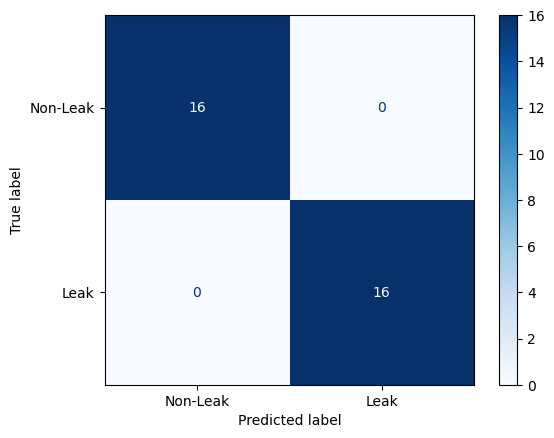

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the class labels for the test set
y_pred_class = (y_pred_proba > 0.5).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Leak", "Leak"])
disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
plt.show()
